# Pairwise rank comparison scatterplots

For each pair of metrics (Half Edge, Dissimilarity, Moran's I), plot cities by their score ranks against each other.

In [21]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

In [ ]:
# CSV_PATHS = ["../../outputs/tracts_in_cbsa/white_poc.csv"]
CSV_PATHS = ["../../outputs/tracts_in_cbsa/white_black.csv"]
    

METRICS = {"half_edge_1": "Half Edge",
    "dissimilarity_1": "Dissimilarity",
    "moran_P": "Moran's I",
    "filename": "filename",
    "total_population": "total_population"}
DISPLAY_METRICS = {"half_edge_1": "Half Edge Rank",
    "dissimilarity_1": "Dissimilarity Rank",
    "moran_P": "Moran's I Rank",}

SELECTED_YEAR = '2020'
GROUPS_COMPARED = re.search(r'([^/]+)\.csv$', CSV_PATHS[0]).group(1) # white_black
if GROUPS_COMPARED == 'white_black':
    GROUPS_COMPARED = 'White and Black'
else:
    GROUPS_COMPARED = 'White and POC'
NODE_AREAS = re.search(r'outputs/([^_]+)_in', CSV_PATHS[0]).group(1) # tracts
STUDY_AREAS = re.search(r'outputs/[^/]+_in_([^/]+)/', CSV_PATHS[0]).group(1) # max_city
if STUDY_AREAS == 'max_city':
    STUDY_AREAS = 'the largest city per metropolitan area'

In [23]:
# load and tag each file with a label derived from its path
frames = []
for path in CSV_PATHS:
    df = pd.read_csv(path, usecols=list(METRICS))
    df["source"] = path.split("/")[-1].replace(".csv", "")
    df["year"] = df["filename"].str.extract(r'(\d{4})')
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data = data.dropna(subset=list(METRICS))

# subset to one year, select top 100 by population
data = data[data['year'] == SELECTED_YEAR]
data = data.sort_values("total_population", ascending=False)[:100]

# rank within each source file
# del METRICS['filename']
for col in DISPLAY_METRICS:
    data[col + "_rank"] = data.groupby("source")[col].rank(method="average")

data.head(3)

,filename,half_edge_1,dissimilarity_1,moran_P,total_population,source,year,half_edge_1_rank,dissimilarity_1_rank,moran_P_rank
1736,data/processed/dual_graphs/2020/tracts_in_cbsa...,0.773753,0.748214,0.846804,20140396,white_black,2020,98.0,99.0,90.0
1697,data/processed/dual_graphs/2020/tracts_in_cbsa...,0.722833,0.636443,0.881057,13200988,white_black,2020,94.0,87.0,97.0
1555,data/processed/dual_graphs/2020/tracts_in_cbsa...,0.776183,0.736921,0.877333,9618502,white_black,2020,99.0,98.0,95.0


Saved → ../../outputs/tracts_in_cbsa/figures/rank_comparisons/white_black_rank_panel.png


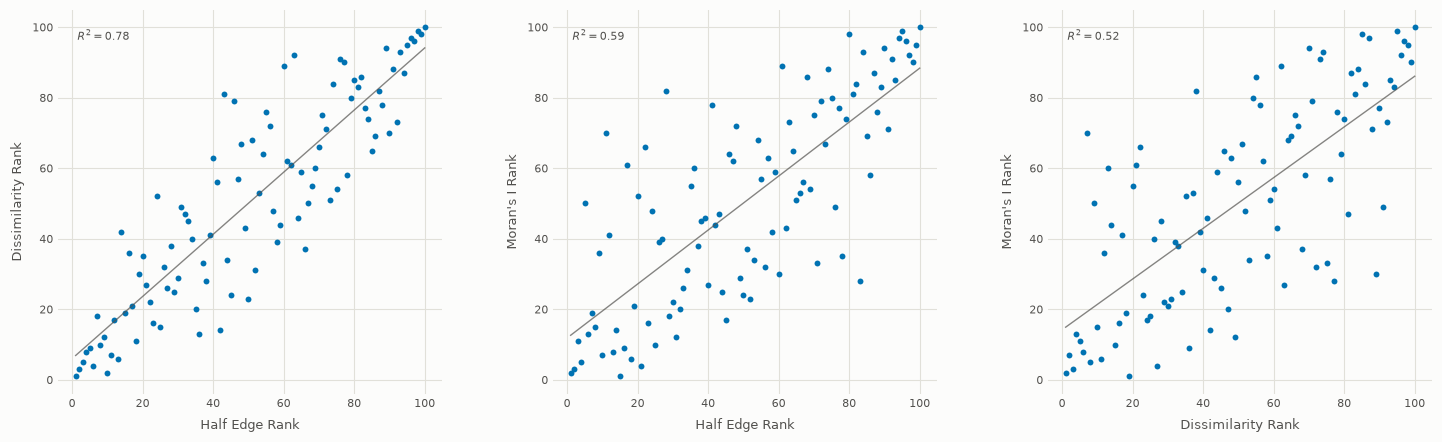

In [24]:
from pathlib import Path

pairs = list(combinations(DISPLAY_METRICS.keys(), 2)) # 3 pairs
sources = data["source"].unique()

BG = "#fcfcfb"
SECONDARY = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
colors = ["#0072b2", "#ffa812", "#8db600", "#ffb7c5"]

fig_prefix = Path(CSV_PATHS[0]).stem  # e.g. "white_black"
out_dir = Path(CSV_PATHS[0]).parent / "figures" / "rank_comparisons"
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5), facecolor=BG)

for ax, (x_col, y_col) in zip(axes, pairs):
    ax.set_facecolor(BG)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.grid(color=GRID, linewidth=0.8, zorder=0)
    ax.tick_params(length=0, labelsize=8, labelcolor=SECONDARY)
    ax.set_box_aspect(1)

    for i, src in enumerate(sources):
        sub = data[data["source"] == src]
        ax.scatter(sub[x_col + "_rank"], sub[y_col + "_rank"],
            s=18, alpha=1,
            color=colors[i % len(colors)],
            label=src, linewidths=0, zorder=2)
        x = sub[x_col + "_rank"]
        y = sub[y_col + "_rank"]
        m, b = np.polyfit(x, y, 1)
        r2 = np.corrcoef(x, y)[0, 1] ** 2
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, m * xline + b, color=SECONDARY, lw=1, alpha=0.7)
        ax.annotate(f"$R^2={r2:.2f}$", xy=(0.05, 0.92), xycoords="axes fraction",
                    fontsize=8, color=SECONDARY)

    ax.set_xlabel(DISPLAY_METRICS[x_col], fontsize=9, color=SECONDARY, labelpad=6)
    ax.set_ylabel(DISPLAY_METRICS[y_col], fontsize=9, color=SECONDARY, labelpad=6)
    # ax.set_title(f"{DISPLAY_METRICS[x_col]}\nvs {DISPLAY_METRICS[y_col]}", fontsize=10)

# fig.text(0.52, 0.94, f"{GROUPS_COMPARED} segregation metrics. Each dot is {STUDY_AREAS}, top 100 cities by population are shown",
#          ha="center", fontsize=9)
# fig.suptitle(f"Pairwise score-rank comparisons in {SELECTED_YEAR}", fontsize=12, y=1.02)

plt.tight_layout()
panel_path = out_dir / f"{fig_prefix}_rank_panel.png"
fig.savefig(panel_path, dpi=200, bbox_inches="tight", facecolor=BG)
print(f"Saved → {panel_path}")
plt.show()

In [25]:
# ── one figure per metric pair ────────────────────────────────────────────────
for x_col, y_col in pairs:
    fig_s, ax_s = plt.subplots(figsize=(5, 5), facecolor=BG)
    ax_s.set_facecolor(BG)
    ax_s.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax_s.grid(color=GRID, linewidth=0.8, zorder=0)
    ax_s.tick_params(length=0, labelsize=8, labelcolor=SECONDARY)
    ax_s.set_box_aspect(1)

    for i, src in enumerate(sources):
        sub = data[data["source"] == src]
        ax_s.scatter(sub[x_col + "_rank"], sub[y_col + "_rank"],
            s=18, alpha=1,
            color=colors[i % len(colors)],
            label=src, linewidths=0, zorder=2)
        x = sub[x_col + "_rank"]
        y = sub[y_col + "_rank"]
        m, b = np.polyfit(x, y, 1)
        r2 = np.corrcoef(x, y)[0, 1] ** 2
        xline = np.linspace(x.min(), x.max(), 100)
        ax_s.plot(xline, m * xline + b, color=SECONDARY, lw=1, alpha=0.7)
        ax_s.annotate(f"$R^2={r2:.2f}$", xy=(0.05, 0.92), xycoords="axes fraction",
                      fontsize=8, color=SECONDARY)

    ax_s.set_xlabel(DISPLAY_METRICS[x_col], fontsize=9, color=SECONDARY, labelpad=6)
    ax_s.set_ylabel(DISPLAY_METRICS[y_col], fontsize=9, color=SECONDARY, labelpad=6)

    out_path = out_dir / f"{fig_prefix}_rank_{x_col}_vs_{y_col}.png"
    fig_s.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=BG)
    plt.close(fig_s)
    print(f"Saved → {out_path}")

Saved → ../../outputs/tracts_in_cbsa/figures/rank_comparisons/white_black_rank_half_edge_1_vs_dissimilarity_1.png
Saved → ../../outputs/tracts_in_cbsa/figures/rank_comparisons/white_black_rank_half_edge_1_vs_moran_P.png
Saved → ../../outputs/tracts_in_cbsa/figures/rank_comparisons/white_black_rank_dissimilarity_1_vs_moran_P.png
